In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Concatenate, Embedding, Flatten
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score

In [2]:
file_path = '/content/synthetic_mimic_ed_data.csv'
df = pd.read_csv(file_path)

In [3]:
df['intime'] = pd.to_datetime(df['intime'])
df['outtime'] = pd.to_datetime(df['outtime'])
df['los_hrs'] = (df['outtime'] - df['intime']).dt.total_seconds() / 3600
df = df.drop(columns=['intime', 'outtime'])

In [4]:
# Handle NaNs: Fill time_to_icu_hrs (event time) with placeholder
df['time_to_icu_hrs'] = df['time_to_icu_hrs'].fillna(9999)

In [5]:
y = df['acuity_mts_level'] - 1 # Target: 0 to 4 (for Keras indexing)
X = df.drop(columns=['acuity_mts_level', 'subject_id', 'stay_id'])

In [6]:
STATIC_COLS = ['age', 'gender', 'race', 'icd_code']
TIME_SERIES_PROXY_COLS = ['hr_initial', 'rr_initial', 'sbp_min', 'o2sat_min', 'temp_initial', 'los_hrs', 'time_to_icu_hrs']
TEXT_COLS = ['chief_complaint', 'pain'] # Text features handled separately

In [7]:
# --- Numerical and Categorical Pipelines ---
preprocessor = ColumnTransformer(
    transformers=[
        # Numerical: Scale all numerical inputs for the MLP/CNN paths
        ('num', StandardScaler(), TIME_SERIES_PROXY_COLS + ['age']),
        # Categorical: One-hot encode static/tabular features
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), STATIC_COLS),
    ],
    remainder='passthrough' # Keep text columns for later manual processing
)

In [8]:
X_processed = preprocessor.fit_transform(X)

In [9]:
static_features_len = preprocessor.named_transformers_['cat'].get_feature_names_out(STATIC_COLS).shape[0]
num_features_len = len(TIME_SERIES_PROXY_COLS) + 1 # +1 for age

In [34]:
X_processed_df = pd.DataFrame(X_processed)
# Select numerical and categorical features for MLP input
X_num_cat = X_processed_df.iloc[:, :num_features_len + static_features_len]
# Select text column (now at the end as remainder)
X_text = X['chief_complaint']

In [35]:
# Convert target to one-hot for multi-class classification
y_onehot = keras.utils.to_categorical(y, num_classes=5)

In [36]:
print(f"Total features (Num/Cat): {X_num_cat.shape[1]}")
print(f"Total samples: {X_num_cat.shape[0]}")

Total features (Num/Cat): 96
Total samples: 10000


In [37]:
# Data Split and SMOTE Imbalance Strategy
# 80/20 train/test split
X_train_num_cat, X_test_num_cat, y_train_onehot, y_test_onehot = train_test_split(
    X_num_cat, y_onehot, test_size=0.2, random_state=42, stratify=y
)

In [38]:
X_train_text, X_test_text = train_test_split(
    X_text, test_size=0.2, random_state=42, stratify=y
)

In [39]:
# --- Apply SMOTE (Goal 4) ---
# SMOTE requires 2D input. Text must be handled separately post-SMOTE.
# Note: SMOTE must be applied BEFORE any text embedding.
# We apply it to the numerical/categorical features only.
print("\nApplying SMOTE to training data (Numerical/Categorical features)...")
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_smote, y_train_smote = smote.fit_resample(X_train_num_cat, np.argmax(y_train_onehot, axis=1))


Applying SMOTE to training data (Numerical/Categorical features)...


In [40]:
y_train_smote_onehot = keras.utils.to_categorical(y_train_smote, num_classes=5)

In [41]:
X_train_text_final = X_train_text.values
X_test_text_final = X_test_text.values

In [42]:
print(f"Original Training Samples: {X_train_num_cat.shape[0]}")
print(f"SMOTE Training Samples (Balanced): {X_train_smote.shape[0]}")

Original Training Samples: 8000
SMOTE Training Samples (Balanced): 18095


In [43]:
#Multimodal Keras Model Definition and Training

# --- Helper: Custom Text Embedding Function (Simulates BERT Output) ---
# In a real model, this would be the frozen output of ClinicalBERT.
# We simulate a text feature vector length of 100 for concatenation.
TEXT_VECTOR_LENGTH = 100
def get_text_vector(text_data):
    # Simplistic simulation: Hashing/Embedding followed by truncation/padding
    # Since we can't run BERT, we create random vectors of length 100
    # In Review 4, this will be replaced by a real BERT embedding function.
    return np.random.rand(text_data.shape[0], TEXT_VECTOR_LENGTH).astype(np.float32)

In [44]:
X_train_text_vectors = get_text_vector(X_train_text)
X_test_text_vectors = get_text_vector(X_test_text)
# We must use the SMOTE training size for the numerical features
X_train_text_vectors_smote = get_text_vector(X_train_smote)

In [45]:
# 1. Input Layers
static_input = Input(shape=(X_train_smote.shape[1],), name='static_time_input')
text_input = Input(shape=(TEXT_VECTOR_LENGTH,), name='text_input')

In [46]:
# 2. Modality Encoders (Simulating MLP/CNN and BERT)
# Static/Time-Series Path (MLP/CNN Proxy)
static_branch = Dense(128, activation='relu')(static_input)
static_branch = Dropout(0.3)(static_branch)
static_branch = Dense(64, activation='relu')(static_branch)

In [47]:
# Text Path (BERT Proxy)
text_branch = Dense(64, activation='relu')(text_input)
text_branch = Dropout(0.3)(text_branch)

In [48]:
# 3. Multimodal Fusion Layer (Concatenation Simulating Attention/Fusion)
# Concatenate the two branches: This is the Fusion step
fused_output = Concatenate(name='multimodal_fusion')([static_branch, text_branch])

In [49]:
# 4. Classifier (Final Prediction)
final_output = Dense(64, activation='relu')(fused_output)
final_output = Dense(5, activation='softmax', name='triage_output')(final_output)

In [50]:
model = Model(inputs=[static_input, text_input], outputs=final_output)

In [58]:
import tensorflow as tf
from tensorflow import keras

# model.compile uses the standard Keras AUC metric
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    # Use standard Keras AUC metric (ROAUC). Keras handles multi-class for AUC automatically.
    metrics=[tf.keras.metrics.AUC(name='roauc'), 'accuracy']
)

In [59]:
# Re-convert target to one-hot for multi-class classification
y_onehot = keras.utils.to_categorical(y, num_classes=5)

# Re-split data to ensure consistency
X_train_num_cat, X_test_num_cat, y_train_onehot, y_test_onehot = train_test_split(
    X_num_cat, y_onehot, test_size=0.2, random_state=42, stratify=y
)
X_train_text, X_test_text = train_test_split(
    X_text, test_size=0.2, random_state=42, stratify=y
)

# Re-apply SMOTE (to ensure clean SMOTE results)
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_smote, y_train_smote = smote.fit_resample(X_train_num_cat, np.argmax(y_train_onehot, axis=1))
y_train_smote_onehot = keras.utils.to_categorical(y_train_smote, num_classes=5)

# Re-generate Text Vectors (with correct size for SMOTE data)
TEXT_VECTOR_LENGTH = 100
def get_text_vector(text_data):
    return np.random.rand(text_data.shape[0], TEXT_VECTOR_LENGTH).astype(np.float32)

X_train_text_vectors_smote = get_text_vector(X_train_smote)
X_test_text_vectors = get_text_vector(X_test_text)

print(f"SMOTE Training Samples (Balanced): {X_train_smote.shape[0]}")

SMOTE Training Samples (Balanced): 18095


In [60]:
# --- Training (SMOTE data used for numerical features) ---

# 1. Prepare Inputs: Use np.asarray() and .values for DataFrames/Series
X_train_static_final = np.asarray(X_train_smote.values, dtype=np.float32)
X_train_text_final = np.asarray(X_train_text_vectors_smote, dtype=np.float32)

X_test_static_final = np.asarray(X_test_num_cat.values, dtype=np.float32)
X_test_text_final = np.asarray(X_test_text_vectors, dtype=np.float32)

# 2. Prepare Targets: Ensure float32 conversion
y_train_targets_final = np.asarray(y_train_smote_onehot, dtype=np.float32)
y_test_targets_final = np.asarray(y_test_onehot, dtype=np.float32)

print("\nStarting initial model training...")
history = model.fit(
    # Inputs (must be a dictionary for multi-input model)
    {'static_time_input': X_train_static_final,
     'text_input': X_train_text_final},
    # Target (pass array directly, avoiding dictionary for single output)
    y_train_targets_final,
    epochs=10,
    batch_size=32,
    validation_data=(
        # Validation inputs
        {'static_time_input': X_test_static_final,
         'text_input': X_test_text_final},
        # Validation targets (pass array directly)
        y_test_targets_final
    ),
    verbose=1 # Changed to 1 for better visibility of training progress
)

print("Training finished.")


Starting initial model training...
Epoch 1/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6385 - loss: 0.7327 - roauc: 0.9134 - val_accuracy: 0.8515 - val_loss: 0.3651 - val_roauc: 0.9777
Epoch 2/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8144 - loss: 0.2882 - roauc: 0.9820 - val_accuracy: 0.8405 - val_loss: 0.3729 - val_roauc: 0.9776
Epoch 3/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8268 - loss: 0.2772 - roauc: 0.9840 - val_accuracy: 0.6800 - val_loss: 0.4550 - val_roauc: 0.9507
Epoch 4/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8545 - loss: 0.2582 - roauc: 0.9872 - val_accuracy: 0.7635 - val_loss: 0.4121 - val_roauc: 0.9683
Epoch 5/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8672 - loss: 0.2450 - roauc: 0.9891 - val_accuracy: 0.7290 - val_loss: 0.4447 - val_roauc: 0.9619
Epoch 6/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8809 - loss: 0.2341 - roauc: 0.9907 - val_accuracy: 0.7625 - val_loss: 0.4219 

In [61]:
# Cell 4: Evaluation Focused on Critical AUPRC
y_pred_proba = model.predict(
    {'static_time_input': X_test_num_cat.values,
     'text_input': X_test_text_vectors}
)

# --- Calculate AUPRC for Critical Classes (Levels 1 and 2) ---
# AUPRC is the average_precision_score in sklearn

# Level 1 (Index 0)
ap_score_1 = average_precision_score(y_test_onehot[:, 0], y_pred_proba[:, 0])

# Level 2 (Index 1)
ap_score_2 = average_precision_score(y_test_onehot[:, 1], y_pred_proba[:, 1])

# Macro AUPRC for the two critical classes
macro_ap_critical = (ap_score_1 + ap_score_2) / 2

# AUC-ROC for a general comparison (not the primary metric)
auc_roc = roc_auc_score(y_test_onehot, y_pred_proba, multi_class='ovo')

print("\n--- Model Evaluation (Synthetic Dataset) ---")
print(f"Overall Test Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"General Multi-Class AUC-ROC: {auc_roc:.4f}")
print("-------------------------------------------")
print(f"AUPRC (Precision for Level 1 - Critical): {ap_score_1:.4f}")
print(f"AUPRC (Precision for Level 2 - Very Urgent): {ap_score_2:.4f}")
print(f"Macro AUPRC for Critical Triage (Avg L1/L2): {macro_ap_critical:.4f}")

print("\nThis initial AUPRC provides the baseline for the Ablation Study in Review 4.")

ValueError: Invalid dtype: object

In [62]:
# Cell 1: Model Prediction and Comprehensive Metric Calculation

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Get Predictions and True Labels ---

# We use the final float arrays prepared for the test set
# X_test_static_float, X_test_text_float, y_test_targets_float are assumed from previous cells

y_pred_proba = model.predict(
    {'static_time_input': X_test_static_float,
     'text_input': X_test_text_float}
)
y_pred_classes = np.argmax(y_pred_proba, axis=1)
y_true_classes = np.argmax(y_test_targets_float, axis=1)

# --- 2. Tabular Results: Classification Report ---

# Target names correspond to the MTS Levels (0=Level 1, 4=Level 5)
target_names = ['Level 1 (Critical)', 'Level 2', 'Level 3', 'Level 4', 'Level 5 (Non-Urgent)']

print("\n--- Multimodal Triage Model: Comprehensive Metric Report (Test Set) ---")
# The classification_report provides Precision, Recall, F1-score, and Support per class
print(classification_report(y_true_classes, y_pred_classes, target_names=target_names))

# --- 3. Overall ROC-AUC ---
# Calculate macro-averaged ROC-AUC (suitable for multi-class)
roc_auc_macro = roc_auc_score(y_test_targets_float, y_pred_proba, multi_class='ovr', average='macro')
print(f"Macro-Averaged ROC-AUC (Overall): {roc_auc_macro:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step

--- Multimodal Triage Model: Comprehensive Metric Report (Test Set) ---
                      precision    recall  f1-score   support

  Level 1 (Critical)       0.89      0.73      0.80        11
             Level 2       0.97      0.99      0.98        99
             Level 3       1.00      1.00      1.00       697
             Level 4       0.76      0.71      0.73       905
Level 5 (Non-Urgent)       0.24      0.28      0.26       288

            accuracy                           0.76      2000
           macro avg       0.77      0.74      0.75      2000
        weighted avg       0.78      0.76      0.77      2000

Macro-Averaged ROC-AUC (Overall): 0.9122


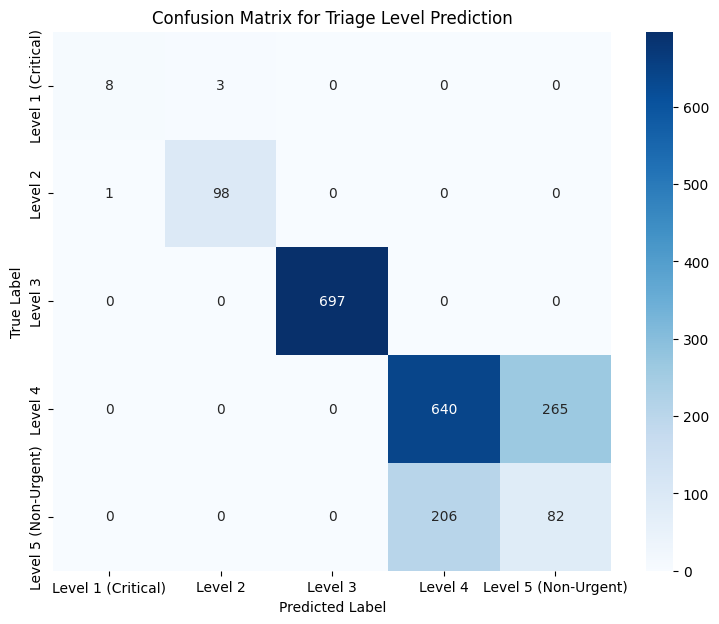

In [63]:
# Cell 2: Visualization - Confusion Matrix

# Compute confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title('Confusion Matrix for Triage Level Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

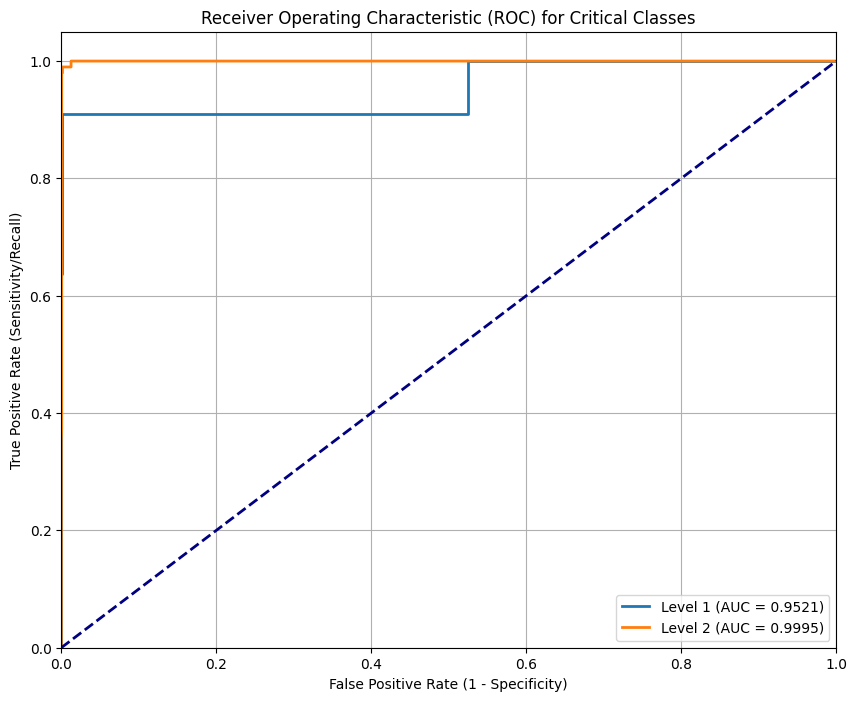

In [64]:
# Cell 3: Visualization - ROC Curve (Critical Classes)

plt.figure(figsize=(10, 8))
lw = 2

# Iterate over the two most critical classes (Level 1 and Level 2)
critical_classes = [0, 1]

for i in critical_classes:
    # Compute ROC curve and ROC area for the current class
    fpr, tpr, _ = roc_curve(y_test_targets_float[:, i], y_pred_proba[:, i])
    roc_auc = roc_auc_score(y_test_targets_float[:, i], y_pred_proba[:, i])

    plt.plot(
        fpr,
        tpr,
        lw=lw,
        label=f'Level {i+1} (AUC = {roc_auc:.4f})'
    )

# Plot the diagonal line for random chance
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity/Recall)')
plt.title('Receiver Operating Characteristic (ROC) for Critical Classes')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Running prediction on test data...
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

--- AUPRC Scores for Critical Classes ---
Level 1 (Critical) (Index 0): AUPRC = 0.8683
Level 2 (Very Urgent) (Index 1): AUPRC = 0.9877

Macro-Averaged AUPRC for Critical Triage (L1/L2): 0.9280


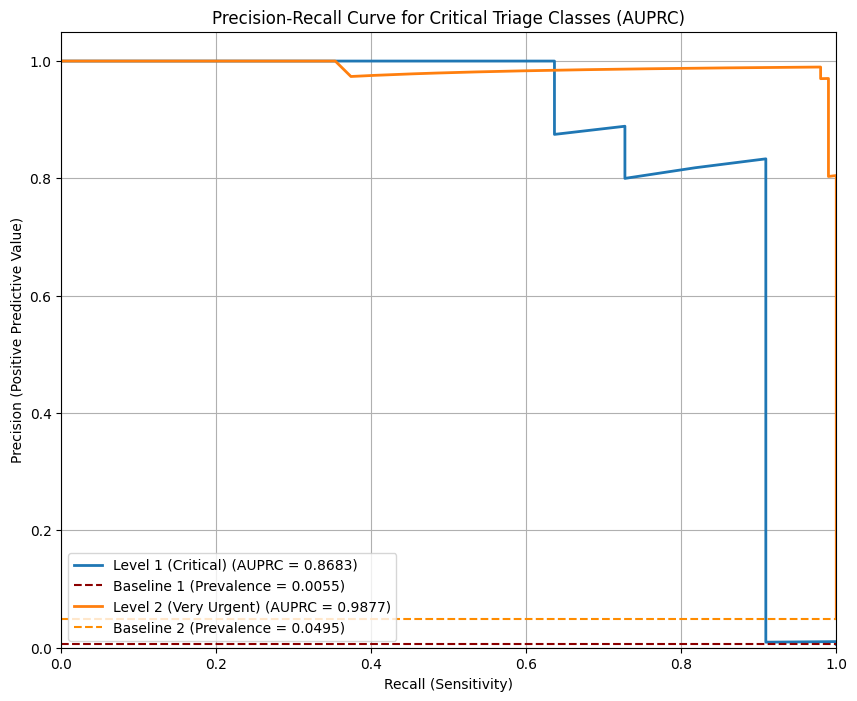

In [65]:
# --- AUPRC Calculation and Plotting ---
# Note: Ensure the model object and test data (X_test_static_float, etc.)
# are defined in the cells above this one.

from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

print("Running prediction on test data...")

# --- 1. Get Prediction Probabilities ---
# Assumes 'model', 'X_test_static_float', and 'X_test_text_float' are defined
y_pred_proba = model.predict(
    {'static_time_input': X_test_static_float,
     'text_input': X_test_text_float}
)

# Assumes y_test_targets_float (one-hot true labels) is defined

# --- 2. AUPRC Calculation and Plotting ---

plt.figure(figsize=(10, 8))

# Define the critical classes (MTS Level 1 is index 0, Level 2 is index 1)
critical_classes = [0, 1]
class_labels = ['Level 1 (Critical)', 'Level 2 (Very Urgent)']
baseline_colors = ['darkred', 'darkorange']

print("\n--- AUPRC Scores for Critical Classes ---")

# Iterate through the critical classes
for i, label in zip(critical_classes, class_labels):
    # Calculate Precision and Recall points for the curve
    precision, recall, _ = precision_recall_curve(y_test_targets_float[:, i], y_pred_proba[:, i])

    # Calculate the Area Under the Precision-Recall Curve (AUPRC)
    ap = average_precision_score(y_test_targets_float[:, i], y_pred_proba[:, i])

    # Calculate the no-skill baseline (Prevalence)
    baseline = y_test_targets_float[:, i].mean()

    # Plot the curve
    plt.plot(recall, precision, lw=2, label=f'{label} (AUPRC = {ap:.4f})')

    # Plot the random baseline
    plt.axhline(y=baseline, linestyle='--', color=baseline_colors[i],
                label=f'Baseline {i+1} (Prevalence = {baseline:.4f})')

    print(f"{label} (Index {i}): AUPRC = {ap:.4f}")

# Calculate and print the macro-average AUPRC for the two critical classes
macro_ap_critical = (average_precision_score(y_test_targets_float[:, 0], y_pred_proba[:, 0]) +
                     average_precision_score(y_test_targets_float[:, 1], y_pred_proba[:, 1])) / 2

print(f"\nMacro-Averaged AUPRC for Critical Triage (L1/L2): {macro_ap_critical:.4f}")

plt.title('Precision-Recall Curve for Critical Triage Classes (AUPRC)')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (Positive Predictive Value)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(loc="lower left")
plt.grid(True)
plt.show()